# GHRSST VIIRS L2P SST - Gulf Stream (multi-granule)

Pulls ~20 VIIRS L2P swath granules over a single ocean basin via NASA Earthdata, concatenates the clear-sky pixels (>1M points after cloud masking), then fits an EFGP with hyper-parameter learning and benchmarks against SKI.

Requires: `pip install earthaccess xarray netCDF4`. The first run will prompt for your NASA Earthdata credentials.

In [28]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
from efgpnd import EFGPND, _resolve_grid

sys.path.append('../../..')
from kernels import SquaredExponential, Matern, ARDSquaredExponential
from utils.ski import fit_ski_gp
from load_ghrsst import download_ghrsst, load_ghrsst_swath, load_ghrsst_torch

In [29]:
# Download up to 20 VIIRS L2P granules over the Gulf Stream for one day.
# Skips the network call if granules are already present in ./data.
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

BBOX = (-80.0, 25.0, -60.0, 45.0)  # lon_min, lat_min, lon_max, lat_max
TARGET_GRANULES = 100

existing = sorted(DATA_DIR.glob('*VIIRS*L2P*.nc')) + sorted(DATA_DIR.glob('*VIIRS*L2P*.nc4'))
if len(existing) >= TARGET_GRANULES:
    granule_paths = existing[:TARGET_GRANULES]
    print(f'Using {len(granule_paths)} cached granules')
else:
    granule_paths = download_ghrsst(
        short_name='VIIRS_NPP-STAR-L2P-v2.80',
        temporal=('2025-06-01', '2025-06-03'),
        bounding_box=BBOX,
        count=TARGET_GRANULES,
        out_dir=DATA_DIR,
    )
    print(f'Downloaded {len(granule_paths)} granules')

for p in granule_paths[:5]:
    print(f'  {p.name}')
if len(granule_paths) > 5:
    print(f'  ... ({len(granule_paths) - 5} more)')

/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

Downloaded 16 granules
  20250601060000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601074000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601154000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601172000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  20250601190000-STAR-L2P_GHRSST-SSTsubskin-VIIRS_NPP-ACSPO_V2.80-v02.0-fv01.0.nc
  ... (11 more)


In [30]:
# Quick preview of the first granule (just to confirm structure / units).
lon_grid, lat_grid, sst_grid, sst_meta = load_ghrsst_swath(
    path=granule_paths[0],
    variable='sea_surface_temperature',
    quality_min=5,
    to_celsius=True,
    bbox=BBOX,
)
valid_sst = np.isfinite(sst_grid)
print(f"Granule time: {sst_meta['time']}")
print(f"Title: {sst_meta['title']}")
print(f"Swath shape: {sst_grid.shape}")
print(f"Valid SST pixels: {valid_sst.sum():,} / {valid_sst.size:,}")
print(f"SST range: {np.nanmin(sst_grid):.2f} to {np.nanmax(sst_grid):.2f} {sst_meta['units']}")

Granule time: 2025-06-01T06:00:01
Title: VIIRS L2P SST
Swath shape: (5392, 3200)
Valid SST pixels: 1,208,136 / 17,254,400
SST range: 2.45 to 30.45 Celsius


In [31]:
# fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
# sst_plot = np.ma.masked_invalid(sst_grid)
# pcm = ax.pcolormesh(lon_grid, lat_grid, sst_plot, cmap='coolwarm', shading='auto', rasterized=True)
# ax.set_title(f"VIIRS L2P SST (single swath) {sst_meta['time']}")
# ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
# ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
# ax.grid(alpha=0.2)
# plt.colorbar(pcm, ax=ax, label=f"SST ({sst_meta['units']})")

In [32]:
# Concatenate clear-sky pixels across ALL granules.
x, y = load_ghrsst_torch(
    path=granule_paths,
    variable='sea_surface_temperature',
    quality_min=5,
    to_celsius=True,
    bbox=BBOX,
    n_sub=None,   # set e.g. 2_000_000 to cap
    seed=0,
)
print(f'x shape: {tuple(x.shape)}')
print(f'y shape: {tuple(y.shape)}')
print(f'Lon range: {x[:, 0].min():.3f} to {x[:, 0].max():.3f}')
print(f'Lat range: {x[:, 1].min():.3f} to {x[:, 1].max():.3f}')
print(f"SST range: {y.min():.2f} to {y.max():.2f} {sst_meta['units']}")

x shape: (10815728, 2)
y shape: (10815728,)
Lon range: -80.000 to -60.000
Lat range: 25.000 to 45.000
SST range: 2.23 to 32.39 Celsius


Text(0.5, 0.98, 'VIIRS L2P SST clear-sky pixels — 16 granules over Gulf Stream')

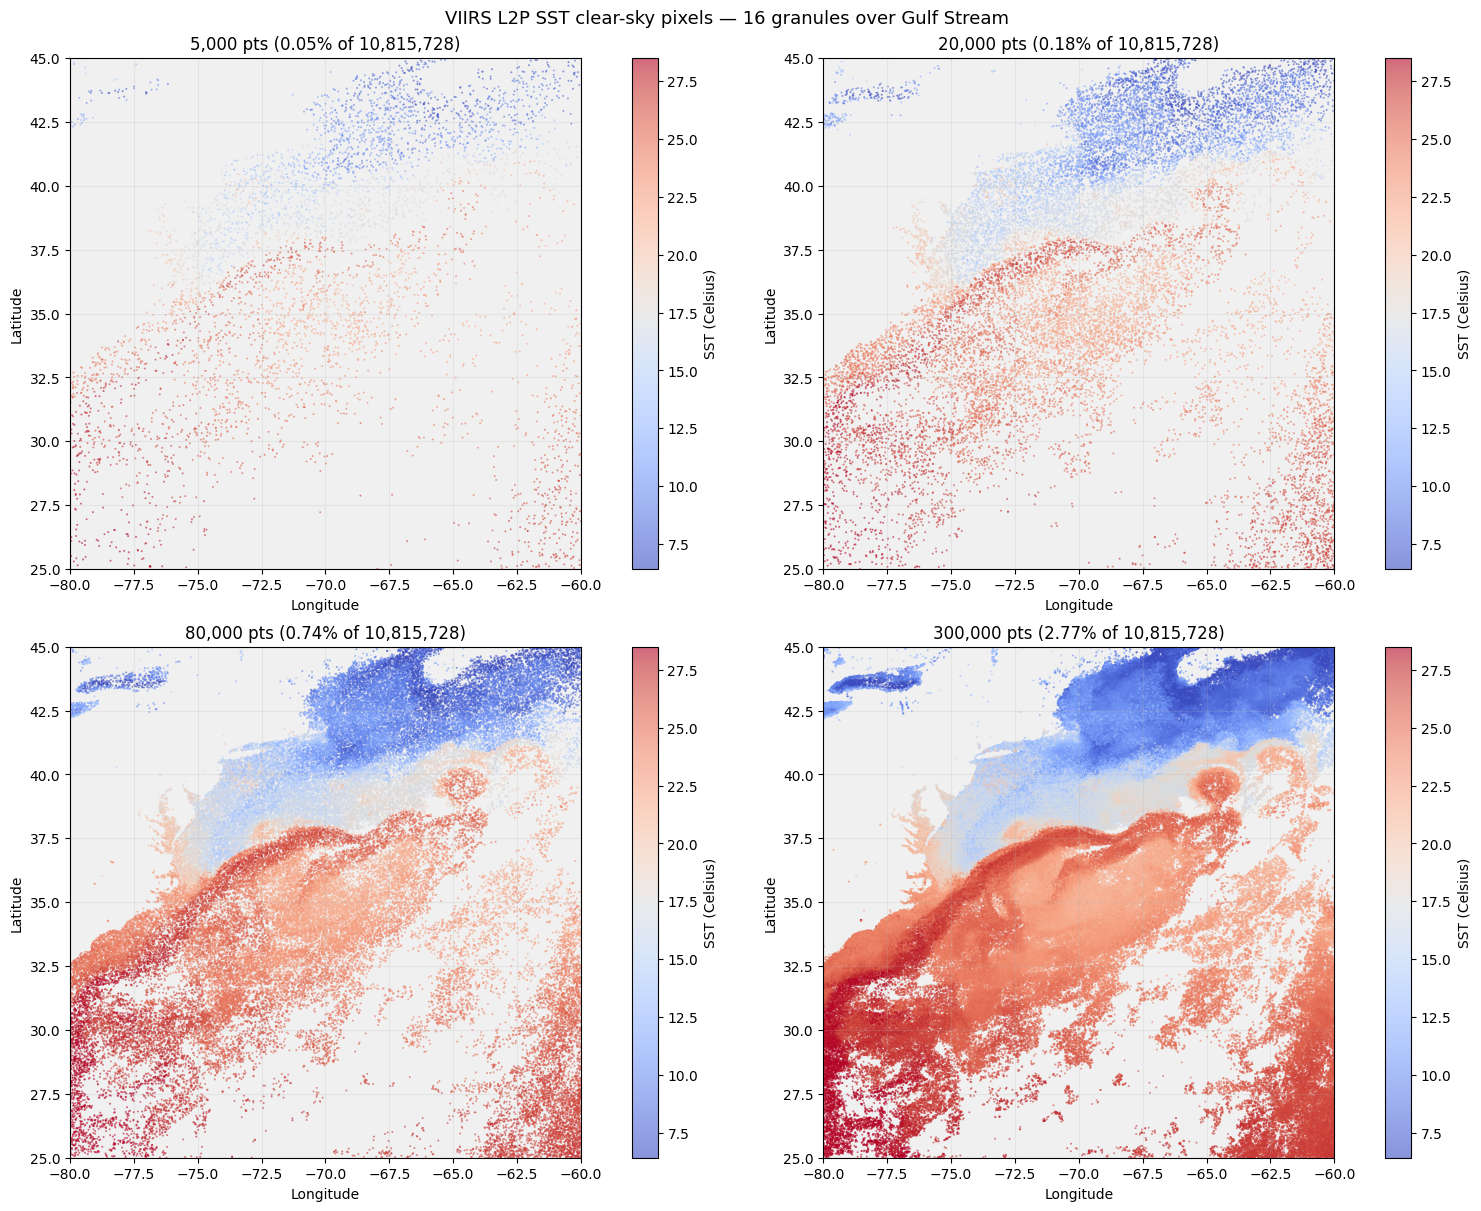

In [33]:
# Visualise the data at a few subsampling rates — too many points and you
# just see a coloured rectangle, too few and you miss the structure.
rng = np.random.default_rng(0)
sample_sizes = [5_000, 20_000, 80_000, 300_000]
vmin = float(np.nanpercentile(y.numpy(), 1))
vmax = float(np.nanpercentile(y.numpy(), 99))

fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)
for ax, n_plot in zip(axes.ravel(), sample_sizes):
    n = min(n_plot, len(y))
    idx = rng.choice(len(y), size=n, replace=False)
    ax.set_facecolor('#f0f0f0')
    sc = ax.scatter(
        x[idx, 0].numpy(), x[idx, 1].numpy(),
        c=y[idx].numpy(), s=2.0, cmap='coolwarm', alpha=0.6,
        vmin=vmin, vmax=vmax, linewidths=0, rasterized=True,
    )
    frac = n / len(y) * 100
    ax.set_title(f'{n:,} pts ({frac:.2f}% of {len(y):,})')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    fig.colorbar(sc, ax=ax, label=f"SST ({sst_meta['units']})")
fig.suptitle(f'VIIRS L2P SST clear-sky pixels — {len(granule_paths)} granules over Gulf Stream', fontsize=13)

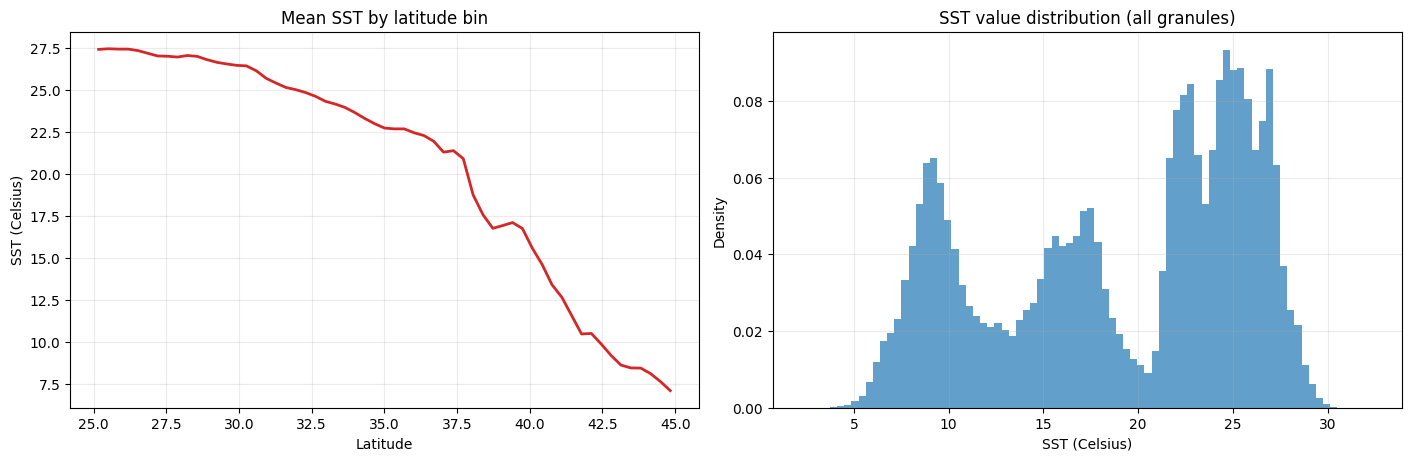

In [34]:
# Distribution + lat-binned mean from the merged point cloud.
y_np = y.numpy()
lat_np = x[:, 1].numpy()
lat_bins = np.linspace(BBOX[1], BBOX[3], 60)
lat_mid = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lat_mean = np.array([
    y_np[(lat_np >= lo) & (lat_np < hi)].mean() if ((lat_np >= lo) & (lat_np < hi)).any() else np.nan
    for lo, hi in zip(lat_bins[:-1], lat_bins[1:])
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
axes[0].plot(lat_mid, lat_mean, color='tab:red', linewidth=2)
axes[0].set_title('Mean SST by latitude bin')
axes[0].set_xlabel('Latitude'); axes[0].set_ylabel(f"SST ({sst_meta['units']})"); axes[0].grid(alpha=0.25)

axes[1].hist(y_np, bins=80, density=True, alpha=0.7, color='tab:blue')
axes[1].set_title('SST value distribution (all granules)')
axes[1].set_xlabel(f"SST ({sst_meta['units']})"); axes[1].set_ylabel('Density'); axes[1].grid(alpha=0.25)

Residual SST: mean=0.274, std=2.339 °C  (raw std was 6.656 °C — trend removed the equator->pole swing)


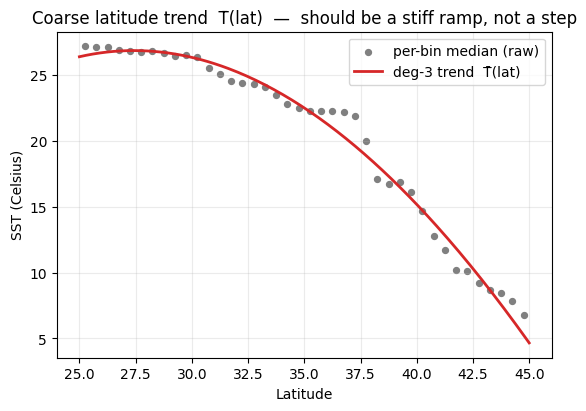

In [35]:
# ---- Coarse latitude de-meaning (two-stage) ----
# Subtract a STIFF zonal profile T̄(lat) so the GP fits residuals: cloud holes then
# revert to the local zonal mean (e.g. ~25 °C in the Sargasso) instead of the global
# mean, killing the "yellow-in-red" off-data artifact. The profile is kept deliberately
# coarse (low-order polynomial through robust per-bin medians) so the sharp Gulf Stream
# FRONT stays in the residual, where the GP models it — NOT aliased into the 1D mean
# (that would smooth the residual and spuriously inflate the fitted lengthscale).
# Plug-in: T̄(lat) is treated as known and added back to the posterior mean at the end;
# at N~3e6 across every latitude band its own uncertainty is negligible, so the std maps
# are unaffected. Run this once, between data load and normalization.
lat_phys = x[:, 1].numpy()
sst_phys = y.numpy()

# Robust per-bin medians, then a low-order (stiff) polynomial weighted by bin counts.
n_lat_bins = 40
lat_edges = np.linspace(lat_phys.min(), lat_phys.max(), n_lat_bins + 1)
lat_ctr = 0.5 * (lat_edges[:-1] + lat_edges[1:])
which = np.clip(np.digitize(lat_phys, lat_edges) - 1, 0, n_lat_bins - 1)
bin_med = np.array([np.median(sst_phys[which == b]) if np.any(which == b) else np.nan
                    for b in range(n_lat_bins)])
bin_cnt = np.array([np.sum(which == b) for b in range(n_lat_bins)], dtype=float)
ok = np.isfinite(bin_med) & (bin_cnt > 0)

TREND_DEG = 3   # low order -> too stiff to chase the front; captures the equator->pole ramp only
coeffs = np.polyfit(lat_ctr[ok], bin_med[ok], deg=TREND_DEG, w=np.sqrt(bin_cnt[ok]))
lat_trend = np.poly1d(coeffs)   # T̄(lat) in physical °C; reused to add the trend back later

# Subtract the trend -> GP fits zero-mean residuals (still in physical °C here).
y = y - torch.as_tensor(lat_trend(lat_phys), dtype=y.dtype)

# Sanity check: the profile MUST look like a smooth monotone ramp — no step at the
# front latitude. A step means the front is leaking into the mean: lower TREND_DEG.
fig, ax = plt.subplots(figsize=(5.5, 4), constrained_layout=True)
ax.scatter(lat_ctr[ok], bin_med[ok], s=18, color='0.5', label='per-bin median (raw)')
lat_fine = np.linspace(lat_phys.min(), lat_phys.max(), 200)
ax.plot(lat_fine, lat_trend(lat_fine), color='tab:red', lw=2, label=f'deg-{TREND_DEG} trend  T̄(lat)')
ax.set_xlabel('Latitude'); ax.set_ylabel(f"SST ({sst_meta['units']})")
ax.set_title('Coarse latitude trend  T̄(lat)  —  should be a stiff ramp, not a step')
ax.legend(); ax.grid(alpha=0.25)
print(f'Residual SST: mean={float(y.mean()):.3f}, std={float(y.std()):.3f} °C  '
      f'(raw std was {sst_phys.std():.3f} °C — trend removed the equator->pole swing)')


In [36]:
# Normalize inputs to [0, 1] and standardize outputs (same convention as OISST notebook).
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f'x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}')
print(f'y mean={y.mean():.4f}, std={y.std():.4f}')

x = x.to(dtype=torch.float32)
y = y.to(dtype=torch.float32)

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=0.0000, std=1.0000


In [37]:
d = x.shape[1]
EPSILON = 1e-3
cg_tol = 1e-4
noise_floor = 1e-4

# Separate lengthscales per axis (ARD). Order matches the x columns: (lon, lat).
# Inputs are normalized to [0, 1] per dim, so these are fractions of the
# bounding-box extent; Adam learns each axis independently from here. EFGP
# builds a *per-dim* Fourier node grid for ARD kernels (see _resolve_grid), so
# a long axis gets fewer nodes than a short one.
init_ls = (0.1, 0.1)   # (ell_lon, ell_lat)
init_var = 1.0
init_noise = 1.0

kernel_efgp = ARDSquaredExponential(
    dimension=d, init_lengthscales=init_ls, init_variance=init_var
)
# Isotropic alternatives (single shared lengthscale):
# kernel_efgp = SquaredExponential(
#     dimension=d, init_lengthscale=0.1, init_variance=init_var
# )
# kernel_efgp = Matern(
#     dimension=d, init_lengthscale=0.1, init_variance=init_var, nu=1.5
# )

# True when the kernel carries per-dimension lengthscales; drives the
# ARD-aware logging / plotting below.
IS_ARD = hasattr(kernel_efgp, 'lengthscales')
print(f'N = {x.shape[0]:,}, d = {d}, ARD = {IS_ARD}')

N = 10,815,728, d = 2, ARD = True


In [38]:
max_iters = 50
REFRESH_EVERY = 10
J = 1


def _ls_vec(ker):
    """Per-dim lengthscales as a python list (length d), ARD or isotropic."""
    if hasattr(ker, 'lengthscales'):
        return [float(v) for v in ker.lengthscales.tolist()]
    return [float(ker.get_hyper('lengthscale'))] * d


# training_log['lengthscale'] holds one length-d list per iter (works for both
# ARD and isotropic kernels).
training_log = {
    'iter': [], 'lengthscale': [], 'variance': [], 'sigmasq': [],
    'mean_cg_iters': [], 'trace_cg_iters': [], 'mtot': [], 'feature_count': [],
    'wall_sec': [], 'grid_refreshed': [],
}

# trace_cg_warm_start and trace_probes_freeze are on by default in EFGPND;
# they pair with REFRESH_EVERY to give the trace solve its warm start.
model = EFGPND(
    x, y, kernel=kernel_efgp, sigmasq=init_noise, eps=EPSILON,
    estimate_params=False,
    opts={"mean_cg_preconditioner_type": "jacobi"},
    # opts={"mean_cg_preconditioner_type": "kronecker"},
)
optimizer = Adam(model.parameters(), lr=0.2)

training_log['iter'].append(0)
training_log['lengthscale'].append(_ls_vec(model.kernel))
training_log['variance'].append(model.kernel.get_hyper('variance'))
training_log['sigmasq'].append(model._gp_params.sig2.item())
for k in ('mean_cg_iters', 'trace_cg_iters', 'mtot', 'feature_count', 'wall_sec', 'grid_refreshed'):
    training_log[k].append(None)

import time as _time

frozen_grid = None
for it in range(max_iters):
    # Rebuild frozen_grid from the *current* hypers every REFRESH_EVERY iters.
    # On all other iters, reuse the previous (xis_1d_list, h_per_dim) so M is
    # stable and the cached mean/trace betas + frozen Hutchinson probes apply.
    if REFRESH_EVERY and it % REFRESH_EVERY == 0:
        xis_1d_list, h_per_dim, _, _ = _resolve_grid(
            model.kernel, model.x, EPSILON,
            rdtype=model.x.dtype, device=model.x.device,
        )
        frozen_grid = (xis_1d_list, h_per_dim)
        refreshed = True
    else:
        refreshed = False

    t0 = _time.perf_counter()
    optimizer.zero_grad()
    model.compute_gradients(
        trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor,
        frozen_grid=frozen_grid,
    )
    optimizer.step()
    dt = _time.perf_counter() - t0

    stats = model.last_gradient_stats
    mean_cg_iters = stats.get('mean_cg_iters')
    trace_cg_iters = stats.get('trace_cg_iters')
    mtot = stats.get('mtot')
    feature_count = stats.get('feature_count')

    ls_vec = _ls_vec(model.kernel)
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it + 1)
    training_log['lengthscale'].append(ls_vec)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(mean_cg_iters)
    training_log['trace_cg_iters'].append(trace_cg_iters)
    training_log['mtot'].append(mtot)
    training_log['feature_count'].append(feature_count)
    training_log['wall_sec'].append(dt)
    training_log['grid_refreshed'].append(refreshed)

    # Print every iter so the warm-start (non-refresh) iters are visible.
    # The leading "*" marks iters where the grid was rebuilt. For ARD, mtot is
    # a per-dim tuple (one node count per axis).
    flag = '*' if refreshed else ' '
    ls_str = ', '.join(f'{v:.4g}' for v in ls_vec)
    print(
        f"{flag} iter {it+1:>3}  {dt:5.2f}s  "
        f"ℓ=({ls_str})  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}  "
        f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}  mtot={mtot}  M={feature_count}"
    )

ls_str = ', '.join(f'{v:.4g}' for v in ls_vec)
print(
    f"\nFinal: ℓ=({ls_str}), σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}, "
    f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}, mtot={mtot}, M={feature_count}"
)
walls = [w for w in training_log['wall_sec'] if w is not None]
refresh_walls = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if r]
warm_walls = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if not r]
print(f"Total wall: {sum(walls):.1f}s")
if refresh_walls and warm_walls:
    print(f"  refresh iters (n={len(refresh_walls)}): mean {sum(refresh_walls)/len(refresh_walls):.2f}s")
    print(f"  warm iters    (n={len(warm_walls)}): mean {sum(warm_walls)/len(warm_walls):.2f}s")

* iter   1   0.48s  ℓ=(0.0826, 0.0826)  σ_f²=1.131  σ_n²=0.8783  cg(mean/trace)=722/134  mtot=19  M=361
  iter   2   0.11s  ℓ=(0.06953, 0.06972)  σ_f²=1.264  σ_n²=0.7663  cg(mean/trace)=722/75  mtot=19  M=361
  iter   3   0.11s  ℓ=(0.05993, 0.06026)  σ_f²=1.4  σ_n²=0.6642  cg(mean/trace)=722/79  mtot=19  M=361
  iter   4   0.10s  ℓ=(0.05275, 0.0531)  σ_f²=1.539  σ_n²=0.5722  cg(mean/trace)=722/94  mtot=19  M=361
  iter   5   0.07s  ℓ=(0.04729, 0.04755)  σ_f²=1.68  σ_n²=0.4903  cg(mean/trace)=460/76  mtot=19  M=361
  iter   6   0.10s  ℓ=(0.04312, 0.04317)  σ_f²=1.827  σ_n²=0.4185  cg(mean/trace)=595/119  mtot=19  M=361
  iter   7   0.08s  ℓ=(0.03995, 0.03967)  σ_f²=1.98  σ_n²=0.3563  cg(mean/trace)=595/57  mtot=19  M=361
  iter   8   0.05s  ℓ=(0.03754, 0.03686)  σ_f²=2.137  σ_n²=0.3038  cg(mean/trace)=182/110  mtot=19  M=361
  iter   9   0.08s  ℓ=(0.03581, 0.0346)  σ_f²=2.299  σ_n²=0.2604  cg(mean/trace)=598/55  mtot=19  M=361
  iter  10   0.09s  ℓ=(0.03464, 0.03279)  σ_f²=2.468  σ_n²=0

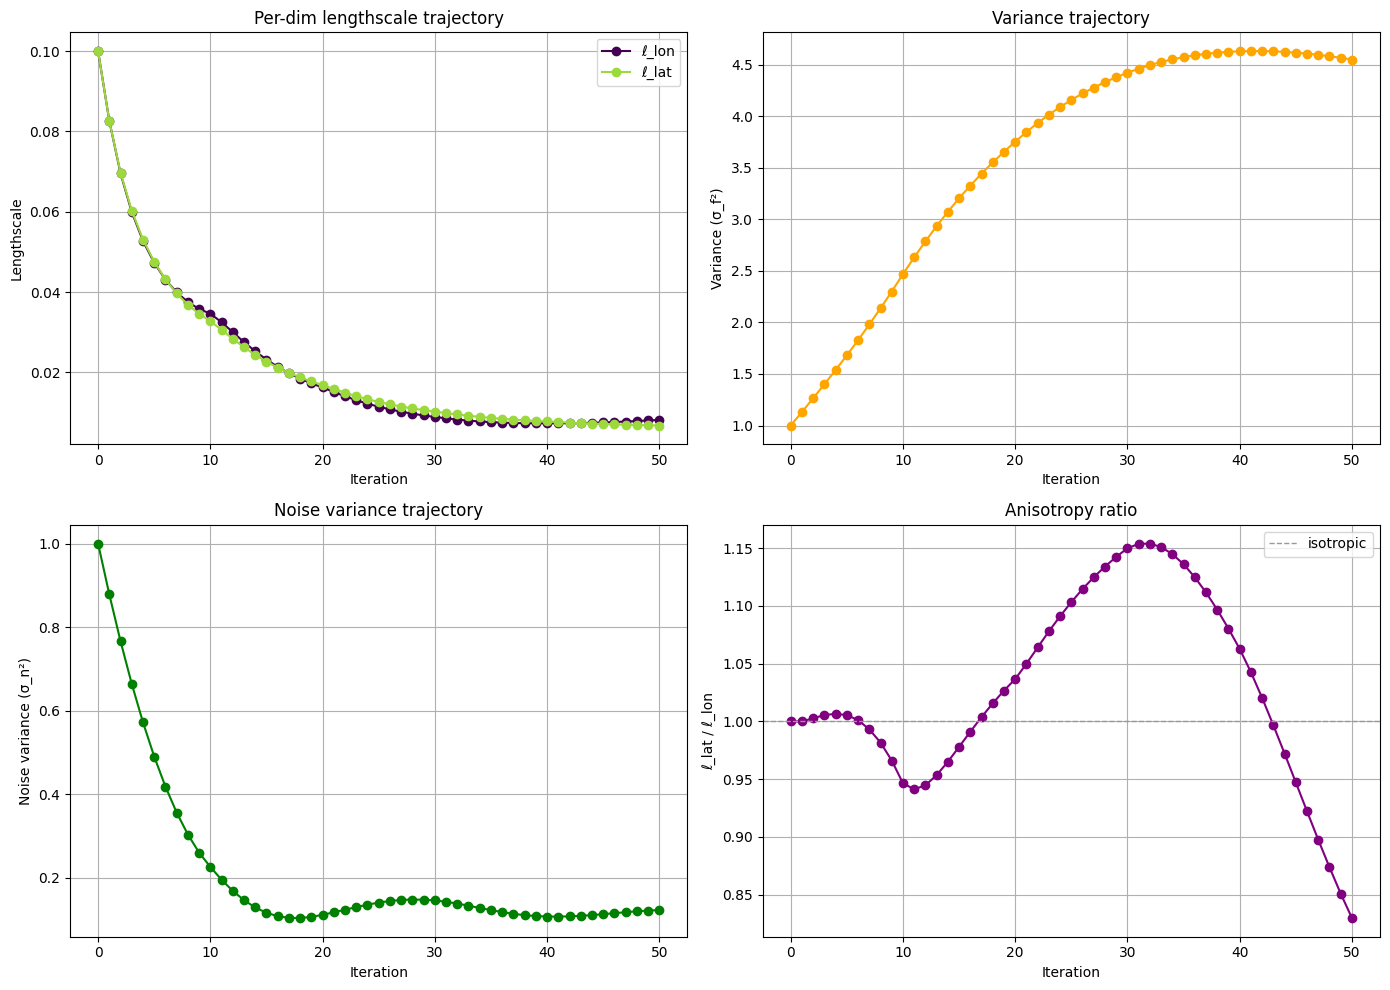

In [39]:
# Hyperparameter trajectories. training_log['lengthscale'] is (n_iters, d):
# one lengthscale per axis when ARD, otherwise the shared value repeated.
ls_arr = np.array(training_log['lengthscale'], dtype=float)  # (n_iters, d)
iters = training_log['iter']
d_ls = ls_arr.shape[1]
ls_labels = ['ℓ_lon', 'ℓ_lat'] if d_ls == 2 else [f'ℓ_{i}' for i in range(d_ls)]
colors = plt.cm.viridis(np.linspace(0.0, 0.85, d_ls))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) per-dim lengthscale trajectories
ax = axes[0, 0]
for j in range(d_ls):
    ax.plot(iters, ls_arr[:, j], 'o-', color=colors[j], label=ls_labels[j])
ax.set_xlabel('Iteration'); ax.set_ylabel('Lengthscale')
ax.set_title('Per-dim lengthscale trajectory'); ax.legend(); ax.grid(True)

# (0,1) signal variance
axes[0, 1].plot(iters, training_log['variance'], 'o-', color='orange')
axes[0, 1].set_xlabel('Iteration'); axes[0, 1].set_ylabel('Variance (σ_f²)')
axes[0, 1].set_title('Variance trajectory'); axes[0, 1].grid(True)

# (1,0) noise variance
axes[1, 0].plot(iters, training_log['sigmasq'], 'o-', color='green')
axes[1, 0].set_xlabel('Iteration'); axes[1, 0].set_ylabel('Noise variance (σ_n²)')
axes[1, 0].set_title('Noise variance trajectory'); axes[1, 0].grid(True)

# (1,1) anisotropy ratio ℓ_lat / ℓ_lon (only meaningful for d >= 2)
ax = axes[1, 1]
if d_ls >= 2:
    ax.plot(iters, ls_arr[:, 1] / ls_arr[:, 0], 'o-', color='purple')
    ax.axhline(1.0, color='0.6', ls='--', lw=1, label='isotropic')
    ax.set_ylabel(f'{ls_labels[1]} / {ls_labels[0]}')
    ax.set_title('Anisotropy ratio'); ax.legend()
else:
    ax.plot(iters, ls_arr[:, 0], 'o-', color='blue')
    ax.set_ylabel('Lengthscale'); ax.set_title('Lengthscale trajectory')
ax.set_xlabel('Iteration'); ax.grid(True)
plt.tight_layout()

## Posterior inference & uncertainty quantification

Predict the EFGP posterior over the Gulf Stream region with the learned hyper-parameters. We map the **posterior mean** SST, then quantify uncertainty with the **pathwise (Matheron)** estimator (`model.predict_pathwise`), which draws posterior functions via smooth-RHS mean solves — fast, non-negative, and it returns the draws themselves. The slower broadband **stochastic (Hutchinson)** estimator is kept at the end as an *optional* comparison.

The mean is masked outside the VIIRS clear-sky footprint; the **variance is left unmasked on purpose**, so you can see the posterior variance rise back to the prior variance away from data.

In [40]:
# ---- Posterior mean over the Gulf Stream region ----
import cartopy.crs as ccrs
import cartopy.feature as cfeature
PC = ccrs.PlateCarree()

def add_coast(ax):
    """Land fill + 50m coastline outline, cropped to BBOX, with lon/lat gridline labels."""
    ax.set_facecolor('#f0f0f0')
    ax.add_feature(cfeature.LAND, facecolor='#cfcfcf', edgecolor='none', zorder=2)
    ax.coastlines(resolution='50m', linewidth=0.6, color='0.3', zorder=3)
    ax.set_extent([BBOX[0], BBOX[2], BBOX[1], BBOX[3]], crs=PC)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='0.8', alpha=0.5)
    gl.top_labels = gl.right_labels = False

# Dense lon/lat grid in the normalized [0, 1] coords used for training.
grid_res = 1_000
g = torch.linspace(0, 1, grid_res, dtype=x.dtype)
G_LON, G_LAT = torch.meshgrid(g, g, indexing='ij')
x_new = torch.stack([G_LON.flatten(), G_LAT.flatten()], dim=1).to(dtype=x.dtype)

# Posterior mean (fast: one CG beta-solve + a single NUFFT). With latitude
# de-meaning this is the RESIDUAL mean (physical °C); we add T̄(lat) back below.
mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred
mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res, grid_res)

# Physical lon/lat for plotting (un-normalize the grid).
lon_pred = G_LON.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item()
lat_pred = G_LAT.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item()

# Add the coarse latitude trend back (plug-in mean): off-data holes now revert to
# T̄(lat), the local zonal mean, instead of the global mean. No-op if not de-meaned.
if 'lat_trend' in globals():
    mean_grid = mean_grid + lat_trend(lat_pred)

# Data-footprint mask: VIIRS clear-sky pixels are a point cloud (land + clouds leave gaps).
# We mask the *mean* outside the footprint; the variance map below is left unmasked.
edges = np.linspace(0, 1, grid_res + 1)
counts, _, _ = np.histogram2d(x[:, 0].numpy(), x[:, 1].numpy(), bins=[edges, edges])
covered = counts > 0
try:
    from scipy.ndimage import binary_dilation
    covered = binary_dilation(covered, iterations=2)
except Exception:
    pass
mean_masked = np.ma.masked_where(~covered, mean_grid)

print(f'Posterior mean on {x_new.shape[0]:,} grid points ({grid_res}x{grid_res}); '
      f'{covered.sum():,} cells inside the data footprint')

Posterior mean on 1,000,000 grid points (1000x1000); 713,288 cells inside the data footprint


Text(0.5, 0.98, 'ℓ=(0.008201, 0.006806),  σ_f²=4.55,  σ_n²=0.123')

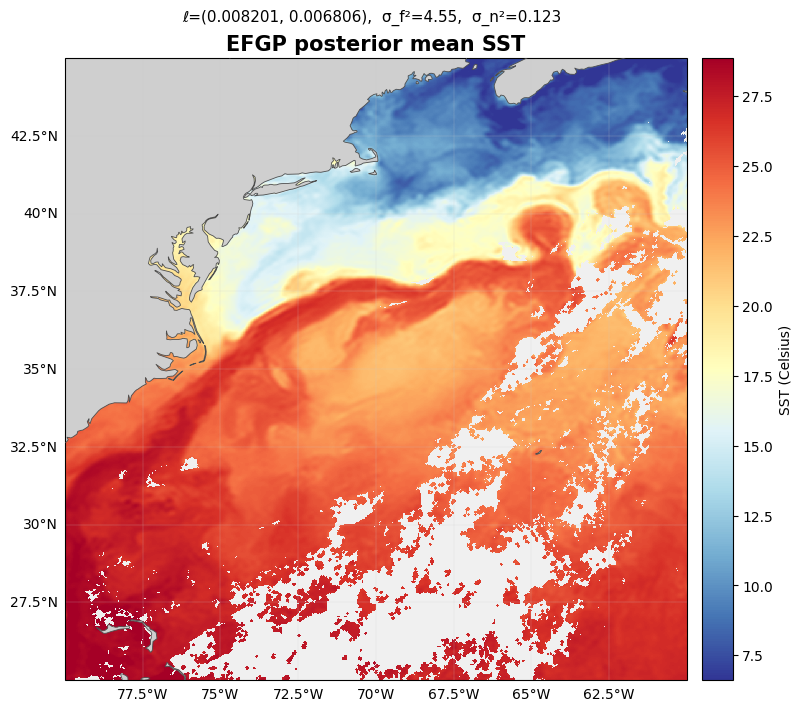

In [41]:
# ---- Posterior mean map ----
ls_vec = (model.kernel.lengthscales.tolist() if hasattr(model.kernel, 'lengthscales')
          else [model.kernel.get_hyper('lengthscale')])
sf2 = model.kernel.get_hyper('variance')
sn2 = model._gp_params.sig2.item()
ell_str = ', '.join(f'{v:.4g}' for v in ls_vec)

fig, ax = plt.subplots(figsize=(8.5, 7), subplot_kw={'projection': PC}, constrained_layout=True)
pcm = ax.pcolormesh(lon_pred, lat_pred, mean_masked, cmap='RdYlBu_r', shading='auto', rasterized=True,
                    transform=PC, vmin=np.percentile(mean_masked.compressed(), 1),
                    vmax=np.percentile(mean_masked.compressed(), 99))
add_coast(ax)
ax.set_title('EFGP posterior mean SST', fontsize=15, fontweight='bold')
fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02).set_label(f"SST ({sst_meta['units']})")
fig.suptitle(f'ℓ=({ell_str}),  σ_f²={sf2:.3g},  σ_n²={sn2:.3g}', fontsize=11)

### Pathwise (Matheron) UQ — two equivalent estimators

Both estimate the **same** posterior variance from Matheron draws (each draw is a smooth-RHS *mean* solve → mean-like CG iterations, non-negative by construction):

- **naive** — `predict_pathwise(...)`: evaluates each draw on the grid (one NUFFT per draw) and takes the empirical variance. Also returns the draws themselves for free.
- **field** — `predict_pathwise(..., field=True)`: folds the draws into the diagonal-sums coefficient field and recovers the whole variance map in a *single* NUFFT. Same estimate (to NUFFT accuracy), and ≈`n_samples`× cheaper to evaluate on a dense grid (large `n_*`); for a handful of query points the naive form is cheaper.

We use the **field** estimate for the std map (dense grid) and the **naive** draws for the example posterior functions. The old broadband diagonal-sums estimator (`variance_method='stochastic'`) is removed for now: its CG cost blows up like √κ at small σ² and it can return negative variances. See `../../../scratch/pathwise_variance.tex`.

In [42]:
# ---- Pathwise (Matheron) UQ: two estimators of the same posterior variance ----
# naive : empirical variance of n_samples draws (also hands back the draws)
# field : same draws folded into the diagonal-sums coefficient field -> a single NUFFT
# Both use smooth-RHS mean solves. See ../../../scratch/pathwise_variance.tex.
import time as _time

n_samples = 8

# naive: var + the free posterior draws (same seed as field -> identical underlying draws)
t0 = _time.perf_counter()
_, samples = model.predict_pathwise(x_new, n_samples=n_samples, return_samples=True, seed=0)
t_naive = _time.perf_counter() - t0
var_naive = samples.pow(2).mean(dim=0)          # mean-of-squares (draws are zero-mean)
print(f'naive: {t_naive:.1f}s')


naive: 9.7s


field: 8.0s
naive: 9.7s   field: 8.0s   (n_samples=8, n_*=1,000,000)
estimates agree to 3.7e-05  (same draws, same estimand; NUFFT-level difference)
prior std = 4.99 Celsius  (posterior std saturates here off-data)


Text(0.5, 0.98, 'Pathwise (Matheron) UQ over the Gulf Stream  (n_samples=8)')

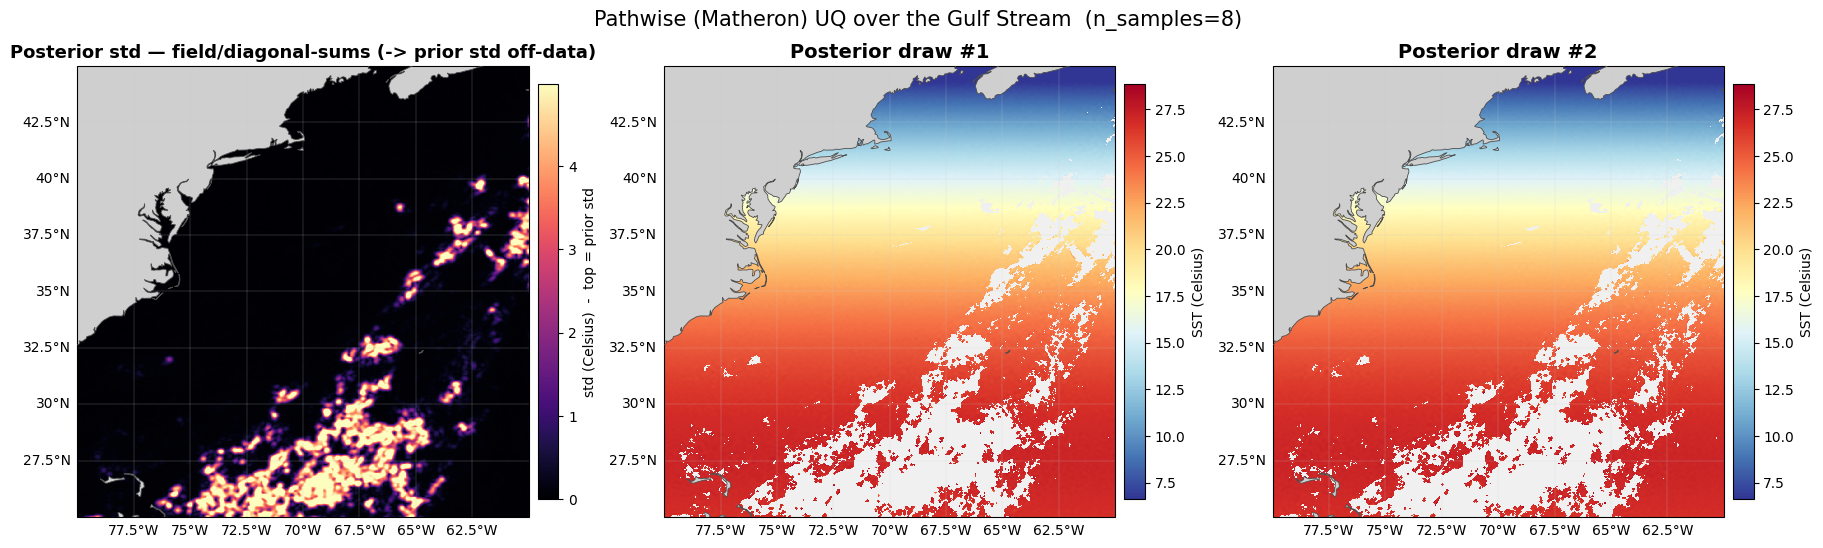

In [43]:

# field (diagonal-sums): the whole variance map in one NUFFT
t0 = _time.perf_counter()
var_field = model.predict_pathwise(x_new, n_samples=n_samples, field=True, seed=0)
t_field = _time.perf_counter() - t0
print(f'field: {t_field:.1f}s')
rel = (torch.linalg.norm(var_field - var_naive) / torch.linalg.norm(var_naive)).item()
print(f'naive: {t_naive:.1f}s   field: {t_field:.1f}s   '
      f'(n_samples={n_samples}, n_*={x_new.shape[0]:,})')
print(f'estimates agree to {rel:.1e}  (same draws, same estimand; NUFFT-level difference)')

# Std map from the field estimate (recommended for dense grids).
var_path = var_field
std_path = (var_path.detach().cpu().clamp_min(0).sqrt() * y_std).numpy().reshape(grid_res, grid_res)
prior_std = float(model.kernel.get_hyper('variance')) ** 0.5 * float(y_std)   # sqrt(sigma_f^2)*y_std
print(f"prior std = {prior_std:.2f} {sst_meta['units']}  (posterior std saturates here off-data)")

# Two example posterior draws (masked to the footprint, in physical units).
# Draws are residual-space; add T̄(lat) back so they read as absolute SST (no-op if not de-meaned).
trend_grid = lat_trend(lat_pred) if 'lat_trend' in globals() else 0.0
draws = [np.ma.masked_where(~covered, (samples[s].detach().cpu() * y_std + y_mean)
                            .numpy().reshape(grid_res, grid_res) + trend_grid) for s in (0, 1)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4), subplot_kw={'projection': PC}, constrained_layout=True)
ax = axes[0]
pcm = ax.pcolormesh(lon_pred, lat_pred, std_path, cmap='magma', shading='auto', rasterized=True,
                    transform=PC, vmin=0.0, vmax=prior_std)   # cap at prior std -> gaps saturate at the prior
add_coast(ax)
ax.set_title('Posterior std — field/diagonal-sums (-> prior std off-data)', fontsize=13, fontweight='bold')
cb = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02)
cb.set_label(f"std ({sst_meta['units']})  -  top = prior std")
for ax, dr, s in zip(axes[1:], draws, (0, 1)):
    pcm = ax.pcolormesh(lon_pred, lat_pred, dr, cmap='RdYlBu_r', shading='auto', rasterized=True,
                        transform=PC, vmin=np.percentile(mean_masked.compressed(), 1),
                        vmax=np.percentile(mean_masked.compressed(), 99))
    add_coast(ax)
    ax.set_title(f'Posterior draw #{s+1}', fontsize=14, fontweight='bold')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.02).set_label(f"SST ({sst_meta['units']})")
fig.suptitle(f'Pathwise (Matheron) UQ over the Gulf Stream  (n_samples={n_samples})', fontsize=15)
# fig.savefig('ghrsst_pathwise_uq.png', dpi=200, bbox_inches='tight')

Text(0.5, 1.03, 'Sea surface temperature over the Gulf Stream  (N = 10,815,728 VIIRS L2P observations, 06/01/2025 to 06/03/2025)')

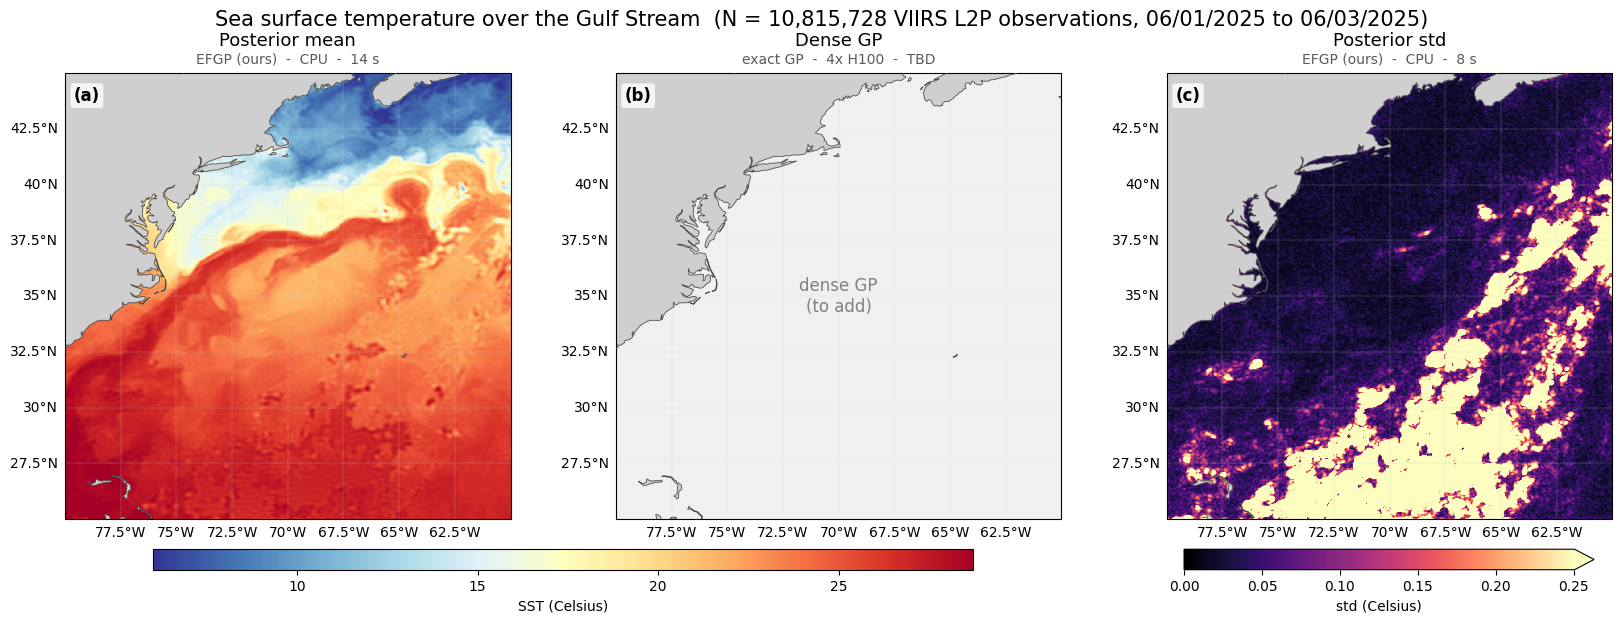

In [49]:
# ---- Paper figure: posterior mean | dense GP | posterior std ----
# Clean three-panel row for the manuscript. Middle panel (dense / exact GP) is
# intentionally left empty for now -- drop the exact-GP mean grid into `dense_grid`
# when it's available and it will render on the same color scale as the EFGP mean.
units = sst_meta['units']
N = x.shape[0]
# Show the posterior mean on the FULL grid (same grid as the variance panel) --
# no footprint masking, so off-data regions revert to the prior mean.
sst_vmin = float(np.percentile(mean_grid, 1))
sst_vmax = float(np.percentile(mean_grid, 99))

# Posterior-std color cap: use the 95th percentile of the std *inside the data
# footprint* (not prior_std), so the colormap spends its full range on the
# uncertainty gradient we can actually see -- off-data regions saturate at the top.
std_vmax = float(np.percentile(std_path[covered], 95))

dense_grid = None  # <- set to a (grid_res, grid_res) array of exact-GP mean SST to fill panel (b)

# Hardware + wall-clock per panel.
#   (a) EFGP: full pipeline incl. hyperparameter learning -> sum of per-iter training wall.
#   (b) Exact GP: full pipeline (hyperparameter learning) -> filled in once we run it.
#   (c) EFGP: variance computation only -> the pathwise `field` solve (`t_field`).
efgp_hw  = 'CPU'        # EFGP runs on a single CPU
exact_hw = '4x H100'    # exact GP baseline (placeholder hardware)

t_efgp  = float(np.nansum([w for w in training_log['wall_sec'] if w is not None]))
t_dense = globals().get('t_dense', None)   # exact-GP pipeline wall (set when available)
t_var   = globals().get('t_field', None)   # pathwise variance solve

def _secs(t):
    return 'TBD' if t is None else (f'{t:.0f} s' if t >= 1 else f'{t*1e3:.0f} ms')

panel_info = [
    ('Posterior mean', f'EFGP (ours)  -  {efgp_hw}  -  {_secs(t_efgp)}'),
    ('Dense GP',       f'exact GP  -  {exact_hw}  -  {_secs(t_dense)}'),
    ('Posterior std',  f'EFGP (ours)  -  {efgp_hw}  -  {_secs(t_var)}'),
]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.9), subplot_kw={'projection': PC},
                         constrained_layout=True)

# (a) EFGP posterior mean (full grid, unmasked)
ax = axes[0]
pcm_mean = ax.pcolormesh(lon_pred, lat_pred, mean_grid, cmap='RdYlBu_r', shading='auto',
                         rasterized=True, transform=PC, vmin=sst_vmin, vmax=sst_vmax)
add_coast(ax)

# (b) Dense GP (gold standard) -- placeholder until the exact-GP solve is in hand
ax = axes[1]
if dense_grid is not None:
    ax.pcolormesh(lon_pred, lat_pred, np.asarray(dense_grid).reshape(grid_res, grid_res),
                  cmap='RdYlBu_r', shading='auto', rasterized=True, transform=PC,
                  vmin=sst_vmin, vmax=sst_vmax)
else:
    ax.text(0.5, 0.5, 'dense GP\n(to add)', transform=ax.transAxes, ha='center', va='center',
            fontsize=12, color='0.5')
add_coast(ax)
# Shared SST colorbar for the two mean panels.
fig.colorbar(pcm_mean, ax=axes[:2], fraction=0.046, pad=0.02, location='bottom',
             shrink=0.85, aspect=40).set_label(f'SST ({units})')

# (c) Posterior std -- cap at 95th pct of in-footprint std; off-data saturates (extend='max')
ax = axes[2]
pcm_std = ax.pcolormesh(lon_pred, lat_pred, std_path, cmap='magma', shading='auto',
                        rasterized=True, transform=PC, vmin=0.0, vmax=std_vmax)
add_coast(ax)
fig.colorbar(pcm_std, ax=ax, fraction=0.046, pad=0.02, location='bottom',
             shrink=0.85, aspect=20, extend='max').set_label(f'std ({units})')

# Titles: method/quantity (bold) + hardware & wall-clock subtitle (gray), plus (a)/(b)/(c).
for ax, (title, detail), label in zip(axes, panel_info, ('a', 'b', 'c')):
    ax.set_title(title, fontsize=13, pad=20)
    ax.text(0.5, 1.015, detail, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=10, color='0.35')
    ax.text(0.02, 0.97, f'({label})', transform=ax.transAxes, ha='left', va='top',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))

fig.suptitle(f'Sea surface temperature over the Gulf Stream  (N = {N:,} VIIRS L2P observations)',
             fontsize=15)
date_range = "06/01/2025 to 06/03/2025"

fig.suptitle(
    f'Sea surface temperature over the Gulf Stream  (N = {N:,} VIIRS L2P observations, {date_range})',
    fontsize=15, y=1.03
)

# fig.savefig('ghrsst_fig_paper.pdf', bbox_inches='tight')
